# 15 Language models and the Transformer

## References

[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)  

### Lectures & videos

[Grant Sanderson (3Blue1Brown)'s LLM videos](https://www.youtube.com/watch?v=LPZh9BOjkQs&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=5)

[Andrew Ng, DeepLearning.ai | C5W3L07 Attention Model Intuition](https://www.youtube.com/watch?v=SysgYptB198)  
[Andrew Ng, DeepLearning.ai | C5W3L08 Attention Model](https://www.youtube.com/watch?v=quoGRI-1l0A)

[Transformers with Lucas Beyer, Google Brain](https://www.youtube.com/watch?v=EixI6t5oif0) ([doc](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit))    

[MIT 6.S191, Recurrent Neural Networks, Transformers, and Attention (2025)](https://www.youtube.com/watch?v=GvezxUdLrEk) ([2024](https://www.youtube.com/watch?v=dqoEU9Ac3ek), [2023](https://www.youtube.com/watch?v=ySEx_Bqxvvo), [2022](https://www.youtube.com/watch?v=QvkQ1B3FBqA))

[Stanford CS224N NLP with Deep Learning | 2024 | Lecture 7 - Attention, Final Projects and LLM Intro](https://www.youtube.com/watch?v=J7ruSOIzhrE&list=PLoROMvodv4rOaMFbaqxPDoLWjDaRAdP9D&index=8) ([2021](https://www.youtube.com/watch?v=wzfWHP6SXxY))  
[Stanford CS224N NLP with Deep Learning | 2023 | Lecture 8 - Self-Attention and Transformers](https://www.youtube.com/watch?v=LWMzyfvuehA&list=PLoROMvodv4rOaMFbaqxPDoLWjDaRAdP9D&index=8)  
[Stanford CS224N NLP with Deep Learning | 2021 | Lecture 7 - Translation, Seq2Seq, Attention](https://www.youtube.com/watch?v=wzfWHP6SXxY)  

[Stanford CS25 Transformers United](https://www.youtube.com/playlist?list=PLoROMvodv4rNiJRchCzutFw5ItR_Z27CM) covering various research topics & transformers.

[Lecture 12.1 Self-attention](https://www.youtube.com/watch?v=KmAISyVvE1Y&list=PLIXJ-Sacf8u60G1TwcznBmK6rEL3gmZmV) ([more lectures](https://www.youtube.com/@dlvu6202/playlists))  

### Blogs, tutorials

[Jay Alammar, "The Illustrated Transformer"](https://jalammar.github.io/illustrated-transformer/)  

[Peter Bloem, "Transformers From Scratch"](https://peterbloem.nl/blog/transformers) (in PyTorch!)  
[The Annotated Transformer](http://nlp.seas.harvard.edu/annotated-transformer/) (same)  

Sebastian Raschka, [LLMs From Scratch](https://sebastianraschka.com/)

[Classify text with BERT](https://www.tensorflow.org/text/tutorials/classify_text_with_bert) (what is done below, without building the net)  
[Neural machine translation with a Transformer and Keras](https://www.tensorflow.org/text/tutorials/transformer) (building the net from scratch, on another task)  
[Huggingface's NLP course](https://huggingface.co/learn/nlp-course/chapter1/1)  
[Tensor2Tensor Colab](https://colab.research.google.com/github/tensorflow/tensor2tensor/blob/master/tensor2tensor/notebooks/hello_t2t.ipynb)  

[Vision Transformers (ViT) Explained](https://www.pinecone.io/learn/vision-transformers/) [(video)](https://www.youtube.com/watch?v=qU7wO02urYU)  
Keras tutorial: [Image classification with Vision Transformer](https://keras.io/examples/vision/image_classification_with_vision_transformer/)

## Attention

<!-- <imgsrc="images/transformer/chollet.attention.2.png"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/chollet.attention.2.png">

DLWP, 2<sup>nd</sup> edition, p.338

### Numpy Visualisation

source.shape = (1, 10, 3)
target.shape = (1, 7, 3)
attn.shape = TensorShape([1, 7, 7])
updated_target.shape = (1, 7, 3)


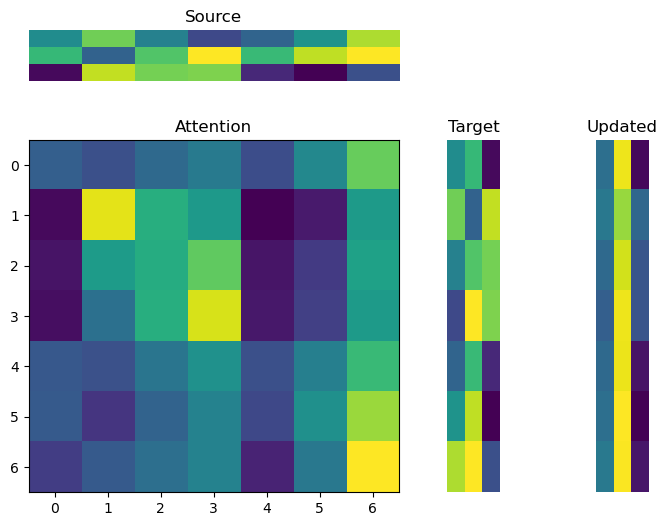

In [3]:
# see: https://chatgpt.com/share/69a0845f-6640-8005-9af5-010b9c9515c6
#      https://chatgpt.com/share/69a9b409-1de0-8005-a39c-1f83ea2e26d6

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
import keras

def dot_product_attention(target, source):
    # Takes the dot-product between all target and source vectors, where
    # b = batch size, t = target length, s = source length, d = vector size
    scores = np.einsum("btd,bsd->bts", target, source)
    scores = keras.ops.softmax(scores, axis=-1)
    # print("scores shape:", scores.shape)
    # Computes a weighted sum of all source vectors for each target vector
    return scores, np.einsum("bts,bsd->btd", scores, source)

# np.random.seed(12)
embedding_dim = 3
source = np.random.uniform(size=(1,10, embedding_dim))
target = np.random.uniform(size=(1,7, embedding_dim))
print(f"{source.shape = }")
print(f"{target.shape = }")

# self-attention, comment this to use the two separate vectors
source = target

attn, updated_target = dot_product_attention(target, source)
print(f"{attn.shape = }")
print(f"{updated_target.shape = }")

S = source.shape[1]
T = target.shape[1]

channel = 0

fig = plt.figure(figsize=(8,6))

# 3 rows, 5 columns (two spacers)
gs = gridspec.GridSpec(
    3, 5,
    width_ratios=[S, 0.1, 1, 1, 1],
    height_ratios=[1, 0.1, T],
)

# Source
ax_source = fig.add_subplot(gs[0,0])
ax_source.imshow(source[0].T, aspect="auto")
ax_source.axis("off")
ax_source.set_title("Source")

# Attention
ax_attn = fig.add_subplot(gs[2,0])
ax_attn.imshow(attn[0], aspect="auto")
ax_attn.set_title("Attention")

# Target
ax_target = fig.add_subplot(gs[2,2], sharey=ax_attn)
ax_target.imshow(target[0], aspect="auto")
ax_target.axis("off")
ax_target.set_title("Target")

# Updated Target
ax_updated = fig.add_subplot(gs[2,4], sharey=ax_attn)
ax_updated.imshow(updated_target[0], aspect="auto")
ax_updated.axis("off")
ax_updated.set_title("Updated")

plt.show()

### Positional Encoding

The original paper had a subtle approach to this, and as often happens there are a few variants out there.

[What is the positional encoding in the transformer model?](https://datascience.stackexchange.com/questions/51065/what-is-the-positional-encoding-in-the-transformer-model)  
[Amirhossein Kazemnejad, "Transformer Architecture: The Positional Encoding"](https://kazemnejad.com/blog/transformer_architecture_positional_encoding/)
[Mehreen Saeed, "A Gentle Introduction to Positional Encoding in Transformer Models, Part 1"](https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/)  
[Mehreen Saeed, "The Transformer Positional Encoding Layer in Keras, Part 2"](https://machinelearningmastery.com/the-transformer-positional-encoding-layer-in-keras-part-2/)

### Causal Masking

To prevent certain positions to be accessed, multiplying them by large negative number translates into a near zero value after the $softmax$. (Below, the white squares will be these negative numbers. Each slot in the matrix on the left can look up information to its left, but not to its right, the 'future'.)

<!-- <img src="images/transformer/masked-attention.png"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/masked-attention.png">

<small>[Peter Bloem, "Transformers From Scratch"](https://peterbloem.nl/blog/transformers)</small>

### Multi-head Attention

<!-- ![Stanford CS224n multi-head attention](images/cs224n/07.multi-head.3.png) -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/07.multi-head.3.png">

[Stanford CS224n, lecture 8](https://web.stanford.edu/class/cs224n/slides/cs224n-2023-lecture08-transformers.pdf#page=8&zoom=auto,-74,536) ([YouTube](https://www.youtube.com/watch?v=LWMzyfvuehA))

### BertViz

Visualise what different heads learn!

<!-- <img src="images/transformer/bertviz.head-view.gif"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/bertviz.head-view.gif">

<small>[BertViz, Visualize Attention in NLP Models](https://github.com/jessevig/bertviz)</small>

## Attention: the maths

### The attention operation

$$
\begin{aligned}
QK^T & =
\begin{pmatrix}
- & q_1 & -\\
- & \vdots & -\\
- & q_{t_X} & - \\
\end{pmatrix}_{t_X \times d_k} \begin{pmatrix}
| & | & |\\
k_1 & \cdots & k_{t_Y}\\
| & | & |\\
\end{pmatrix}_{d_k \times t_Y} =
\begin{pmatrix}
q_1 k_1 & \cdots & q_1 k_{t_Y}\\
\vdots & \cdots & \vdots \\
q_{t_X} k_1 & \cdots & q_{t_X} k_{t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \\
\\
& =
\begin{pmatrix}
w_{11} & \cdots & w_{1 t_Y}\\
\vdots & \cdots & \vdots \\
w_{t_X1} & \cdots & w_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \\
\\
& \rightarrow \begin{pmatrix}
\frac{w_{11}}{\sqrt{d_k}} & \cdots & \frac{w_{1 t_Y}}{\sqrt{d_k}}\\
\vdots & \cdots & \vdots \\
\frac{w_{t_X 1}}{\sqrt{d_k}} & \cdots & \frac{w_{t_X t_Y}}{\sqrt{d_k}}\\
\end{pmatrix}_{t_X \times t_Y}
\end{aligned}
$$

Again, more often than not $t_X = t_Y$, therefore the attention matrix is square.

The number $w_{ij}$ describes who similar/close $q_i$ (the query for token i in the source) is to $k_j$ (the key for token j in the context).

Then we normalize along the rows, so that the numbers in each can be interpreted as weighting factors:

$$
\begin{pmatrix}
softmax( w_{11} & \cdots & w_{1 t_Y})\\
\vdots & \cdots & \vdots \\
softmax(w_{t_X 1} & \cdots & w_{t_X t_Y})\\
\end{pmatrix} =
\begin{pmatrix}
\frac{e^{ w_{11} } }{ \sum_i e^{w_{1i}} } & \cdots & \frac{e^{ w_{1 t_Y} } }{ \sum_i e^{w_{1i}} }\\
\vdots & \cdots & \vdots \\
\frac{e^{ w_{t_X 1} } }{ \sum_i e^{w_{t_X i} } } & \cdots & \frac{e^{ w_{d_k t_Y} } }{ \sum_i e^{w_{t_X i}} }\\
\end{pmatrix}  =
\begin{pmatrix}
w'_{11} & \cdots & w'_{1 t_Y}\\
\vdots & \cdots & \vdots \\
w'_{t_X 1} & \cdots & w'_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} = A
$$


Mix the values using the normalized weights:

$$
\begin{aligned}
softmax(QK^T)V = A V & =
\begin{pmatrix}
- & w'_1 & -\\
- & \vdots & - \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
- & v_1 & -\\
- & \cdots & -\\
- & v_{t_Y} & - \\
\end{pmatrix}_{t_Y \times d_{out}}\\
\\
& =
\begin{pmatrix}
- & x'_1 & -\\
- & \vdots & - \\
- & x'_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}} = X'
\end{aligned}
$$

$X'$ is our output matrix (`timesteps_x`, `embedding_dim_x_prime`) composed of all $x'_i$ vectors representing each updated, 'enriched' tokens (having incorporated information from $Y$). More often than not, $d_{out} = d_X$, the embedding dimension of the output is the same as the one of the input.


Each new vector $v_i$ merges the all the dimensions of the previous vectors $v$ according to the weighting given by $w$:

$$
\begin{aligned}
& \begin{pmatrix}
- & w'_1 & -\\
- & \cdots & - \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
- & v_1 & -\\
- & \vdots & -\\
- & v_{t_Y} & - \\
\end{pmatrix}_{t_Y \times d_{out}} = \\
\\
= & \begin{pmatrix}
- & \color{red}{w'_1} & -\\
\vdots & \cdots & \vdots \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
\overbrace{\color{blue}{v_{11}}}^{ \color{blue}{v'_1}\text{: first dim across all } t_Y } & \cdots & v_{1 d_{out}} \\
\vdots & \cdots & \vdots \\
\color{blue}{v_{t_Y 1}} & \cdots & v_{t_Y  d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} \\
\\
= & \begin{pmatrix}
\color{red}{w'_{11}} \color{blue}{v'_1} & \cdots & x'_1 & -\\
- & \cdots & \vdots & - \\
- & \cdots & x'_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}}
\end{aligned}
$$

$\color{red}{w_1}$, in this example, will control how much each of the $v$s will contribute to new, updated vector $x'_1$ (our updated vector representation for token 1).

Each $o_i$ will have aggregated information from all $v$ (including itself) using the normalised weighting $w_i$.


### Masking

What happens when we use causal masking?

$$
\begin{aligned}
\begin{pmatrix}
w_{11} & - \infty & - \infty & \cdots & - \infty\\
w_{21} & w_{22} & - \infty & \cdots & - \infty\\
\vdots & \cdots & \cdots & \cdots& \vdots \\
w_{t_X 1} & \cdots & \cdots & w_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
v_{11} & \cdots & v_{1 d_{out}} \\
v_{21} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
v_{t_Y 1} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} & \rightarrow\\
\begin{pmatrix}
softmax( w_{11} & - \infty & - \infty & \cdots& - \infty)\\
softmax(w_{21} & w_{22} & - \infty  &\cdots & - \infty)\\
\vdots & \cdots & \cdots & \cdots & \vdots \\
softmax(w_{t_X 1} & \cdots & \cdots & \cdots& w_{t_X t_Y})\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
v_{11} & \cdots & v_{1 d_{out}} \\
v_{21} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
v_{t_Y 1} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} & \rightarrow \\
\begin{pmatrix}
\color{red}{w'_{11} (=1)} & 0 & 0 & \cdots & 0\\
\color{green}{w'_{21}} & \color{green}{w'_{22}} & 0 & \cdots & 0\\
\vdots & \cdots & \cdots & \cdots & \vdots \\
\color{orange}{w'_{t_X 1}} & \cdots & \cdots & \cdots &  \color{orange}{w'_{t_X t_Y}} \\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
\color{blue}{v_{11}} & \cdots & v_{1 d_{out}} \\
\color{blue}{v_{21}} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
\color{blue}{v_{t_Y 1}} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}}  &=
\begin{pmatrix}
\color{red}{w'_{11} (=1)} \color{blue}{v_{11}} & \cdots & y_1 & - \\
\color{green}{w'_{21}} \color{blue}{v_{11}} + \color{green}{w'_{22}} \color{blue}{v_{21}} & \cdots & y_2 & -\\
\vdots & \cdots & \vdots & - \\
\sum_i \color{orange}{w_{t_X i}} \color{blue}{v_{i1}} & \cdots & y_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}}
\end{aligned}
$$

$y_1$ only aggregates itself, $y_2$ aggregates itself and $y_1$, and $y_{d_k}$ aggregates all rows (all time steps).


### Multi-head attention: the maths

Split $Q$ and $K$ along the embedding dimension (the last one):
$$
Q = \begin{pmatrix}
- & \cdots & q_1 & \cdots & -\\
- & \cdots &  \vdots & \cdots & -\\
- & \cdots &  q_{t_X} & \cdots & - \\
\end{pmatrix}_{t_X \times d_k} \rightarrow Q^{h_1} = \begin{pmatrix}
- q_1^{h_1} -\\
\vdots\\
- q_{t_X}^{h_1} - \\
\end{pmatrix}_{t_X \times d_h}, Q^{h_2} = \begin{pmatrix}
- q_1^{h_2} -\\
\vdots\\
- q_{t_X}^{h_2} - \\
\end{pmatrix}_{t_X \times d_h}, \cdots
$$

$d_h$ is the dimension of the embedding dimension after division ($d_h = \lfloor d_k / \text{num\_heads} \rfloor)$, with usually a check forcing $d_k$ to be divisible by `num_heads` without remainder.

$$
K^T = \begin{pmatrix}
| & | & |\\
\vdots & \vdots & \vdots \\
k_1 & \cdots & k_{t_Y}\\
\vdots & \vdots & \vdots \\
| & | & |\\
\end{pmatrix}_{d_k \times t_Y} \rightarrow \begin{array}{11}
K^{Th_1} & = \begin{pmatrix} \
| &  & |\\
k_1^{h_1} & \cdots & k_{t_Y}^{h_1}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y},\\
\\
K^{Th_2} & = \begin{pmatrix} \
| &  & |\\
k_1^{h_2} & \cdots & k_{t_Y}^{h_2}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y},\\
& \vdots \ \ \ \ \ \ \ \ \
\end{array}
$$

Compute each of the attention submatrices:

$$
\begin{aligned}
Q^{h_1} K^{Th_1} = \begin{pmatrix}
- q_1^{h_1} -\\
\vdots\\
- q_{t_X}^{h_1} - \\
\end{pmatrix}_{t_X \times d_h} \begin{pmatrix}
| &  & |\\
k_1^{h_1} & \cdots & k_{t_Y}^{h_1}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y} & = \begin{pmatrix}
w_{11}^{h_1} & \cdots & w_{1 t_Y}^{h_1}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_1} & \cdots & w_{t_X t_Y}^{h_1}\\
\end{pmatrix}_{t_X \times t_Y} = A^{h_1}, \\
\\
Q^{h_2} K^{Th_2} = \begin{pmatrix}
- q_1^{h_2} -\\
\vdots\\
- q_{t_X}^{h_2} - \\
\end{pmatrix}_{t_X \times d_h} \begin{pmatrix}
| &  & |\\
k_1^{h_2} & \cdots & k_{t_Y}^{h_2}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y} & = \begin{pmatrix}
w_{11}^{h_2} & \cdots & w_{1 t_Y}^{h_2}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_2} & \cdots & w_{t_X t_Y}^{h_2}\\
\end{pmatrix}_{t_X \times t_Y}  = A^{h_2}, \\
\\
& \vdots
\end{aligned}
$$

Each of those is the same size as our original attention matrix (`input_seq_len` x `context_seq_len`), but the actual number of operations to produce those is the same.

Peform the scaling, softmax and masking as before, then perform the matrix multiplication with the values, themselves split in the same way along the embedding axis:

$$
\begin{aligned}
A^{h_1} V^{h_1} = \begin{pmatrix}
w_{11}^{h_1} & \cdots & w_{1 t_Y}^{h_1}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_1} & \cdots & w_{t_X t_Y}^{h_1}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
- & v_1^{h_1} & -\\
- & \vdots & -\\
- & v_{t_Y}^{h_1} & - \\
\end{pmatrix}_{t_Y \times d_h} & = \begin{pmatrix}
- & x_1^{h_1} & -\\
- & \vdots & - \\
- & x_{t_X}^{h_1} &  -\\
\end{pmatrix}_{t_X \times d_h} = X'^{\ h_1}, \\
\\
A^{h_2} V^{h_2} = \begin{pmatrix}
w_{11}^{h_2} & \cdots & w_{1 t_Y}^{h_2}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_2} & \cdots & w_{t_X t_Y}^{h_2}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
- & v_1^{h_2} & -\\
- & \vdots & -\\
- & v_{t_Y}^{h_2} & - \\
\end{pmatrix}_{t_Y \times d_h} & = \begin{pmatrix}
- & x_1^{h_2} & -\\
- & \vdots & - \\
- & x_{t_X}^{h_2} &  -\\
\end{pmatrix}_{t_X \times d_h} = X'^{\ h_2}, \\
\\
& \vdots
\end{aligned}
$$

Finally, concatenate the result to obtain a matrix of the same shape as the one we would have had without the multi-head split:

$$
\begin{bmatrix}
 X'^{\ h_1} & X'^{\ h_2} & \cdots
\end{bmatrix} =
\begin{pmatrix}
- & x_1^{h_1} & -, &  - & x_1^{h_2} & -, & \cdots \\
- & \vdots & -, & - & \vdots & -, & \cdots \\
- & x_{t_X}^{h_1} & -, & - & x_{t_X}^{h_2} &  -, & \cdots \\
\end{pmatrix}_{t_X \times d_{out}} = \begin{pmatrix}
- & \cdots & x'_1 & \cdots & -\\
- & \cdots & \vdots & \cdots & - \\
- & \cdots & x'_{t_X} & \cdots &  -\\
\end{pmatrix}_{t_X \times d_{out}}
$$

## History

### Seq-to-Seq -> Seq-to-Seq + Attention -> Attention Is All You Need

Attention was first developed to complement recurrent seq2seq models. "Attention Is All You Need" showed you could dispense with the recurrent mechanism altogether.

<!-- <img src="images/nlp/seq2seq-nmt-model-fast.gif"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/nlp/seq2seq-nmt-model-fast.gif">

<small>[Google seq2seq documentation](https://google.github.io/seq2seq/)</small>

<!-- <img src="images/transformer/apply_the_transformer_to_machine_translation.gif"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/apply_the_transformer_to_machine_translation.gif">

<small>["Neural machine translation with a Transformer and Keras", TensorFlow](https://www.tensorflow.org/text/tutorials/transformer)  
The paper: [Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

### Transormers: before & after

<!-- <img style="float:right;height:650px" src="images/transformer/beyer.takeover.1.png"> -->
<img style="float:right;height:650px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.takeover.1.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

<!-- <img style="float:right;height:650px" src="images/transformer/beyer.takeover.2.png"> -->
<img style="float:right;height:650px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.takeover.2.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

## Comparisons of various NLP approaches

<!-- ![Chollet types of language modles](images/chollet/chollet.types-of-lms.346.png) -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/chollet/chollet.types-of-lms.346.png">

DLWP, 2<sup>nd</sup> edition, p.346